# Telecom X - Parte 2

Este notebook reutiliza el flujo de limpieza y transformacion del proyecto anterior (`TELECOMX_LATAM-CHALLENGE`) para construir un pipeline predictivo de churn consistente y reproducible.

## Objetivos del reto

- Usar el mismo dataset ya tratado en la Parte 1.
- Preparar los datos para modelado eliminando columnas irrelevantes o redundantes.
- Analizar correlaciones y patrones clave asociados al churn.
- Entrenar al menos dos modelos de clasificacion.
- Evaluar su desempeno y extraer conclusiones accionables para retencion.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del repositorio.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from telecomx_churn.pipeline import (
    compare_models,
    extract_and_clean_data,
    get_categorical_rate_table,
    get_feature_importances,
    get_numeric_summary_by_churn,
    get_preprocessing_summary,
    plot_class_distribution,
    plot_confusion_matrices,
    plot_correlations,
    plot_directed_analysis,
    plot_feature_importance,
    prepare_modeling_dataset,
    set_plot_theme,
    split_dataset,
    MODEL_DROP_COLUMNS,
)

set_plot_theme()
RAW_DATA_PATH = REPO_ROOT / "data" / "raw" / "TelecomX_Data.json"
PROCESSED_DATA_PATH = REPO_ROOT / "data" / "processed" / "telecomx_clean.csv"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Extraccion del archivo tratado

Se carga el JSON original copiado al nuevo repositorio y se aplica exactamente la misma limpieza y transformacion realizada en la Parte 1. Despues se persiste un CSV tratado para asegurar continuidad entre ambos retos.

In [2]:
clean_df = extract_and_clean_data(RAW_DATA_PATH)
clean_df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Dataset limpio guardado en: {PROCESSED_DATA_PATH}")
print(f"Shape final: {clean_df.shape}")
clean_df.head()

Dataset limpio guardado en: C:\Users\edumo\OneDrive\Documents\New project\CHALLENGE-TELECOM-X_2\data\processed\telecomx_clean.csv
Shape final: (7043, 25)


,customer_id,churn,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,...,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_flag,daily_charges,total_services,senior_citizen_label
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,One year,Yes,Mailed check,65.6,593.30,0,2.186667,5,No
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,Yes,Month-to-month,No,Mailed check,59.9,542.40,0,1.996667,4,No
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Month-to-month,Yes,Electronic check,73.9,280.85,1,2.463333,3,No
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1,3.266667,6,Yes
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Month-to-month,Yes,Mailed check,83.9,267.40,1,2.796667,4,Yes


## 2. Preparacion de datos

Para el modelado se eliminan las siguientes columnas:

- `customer_id`: identificador unico sin valor predictivo.
- `churn`: version categorial del target ya convertida a `churn_flag`.
- `senior_citizen_label`: duplicado de `senior_citizen`.
- `daily_charges`: transformacion lineal exacta de `monthly_charges`, removida para reducir colinealidad.

In [3]:
pd.DataFrame(
    {
        "column_removed": MODEL_DROP_COLUMNS,
        "reason": [
            "Identificador unico",
            "Target duplicado en texto",
            "Duplicado categorico de una variable binaria",
            "Variable redundante derivada de monthly_charges",
        ],
    }
)

,column_removed,reason
0,customer_id,Identificador unico
1,churn,Target duplicado en texto
2,senior_citizen_label,Duplicado categorico de una variable binaria
3,daily_charges,Variable redundante derivada de monthly_charges


In [4]:
preprocessing_summary = get_preprocessing_summary(clean_df)
preprocessing_summary

,class_name,clients,share_pct
0,No,5174,73.46
1,Yes,1869,26.54


La proporcion de churn es cercana al 26.5%, por lo que existe un desbalance moderado, pero no extremo. En lugar de aplicar SMOTE u oversampling, se utiliza:

- separacion estratificada entre entrenamiento y prueba
- `class_weight` en ambos modelos

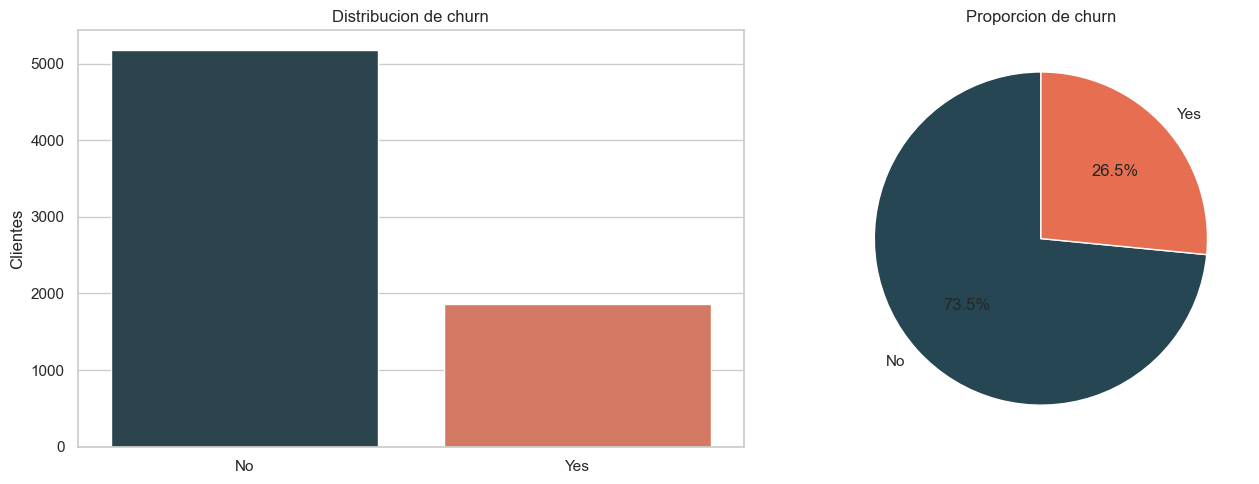

In [5]:
fig = plot_class_distribution(clean_df)
fig.savefig(FIGURES_DIR / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Correlacion y seleccion de variables

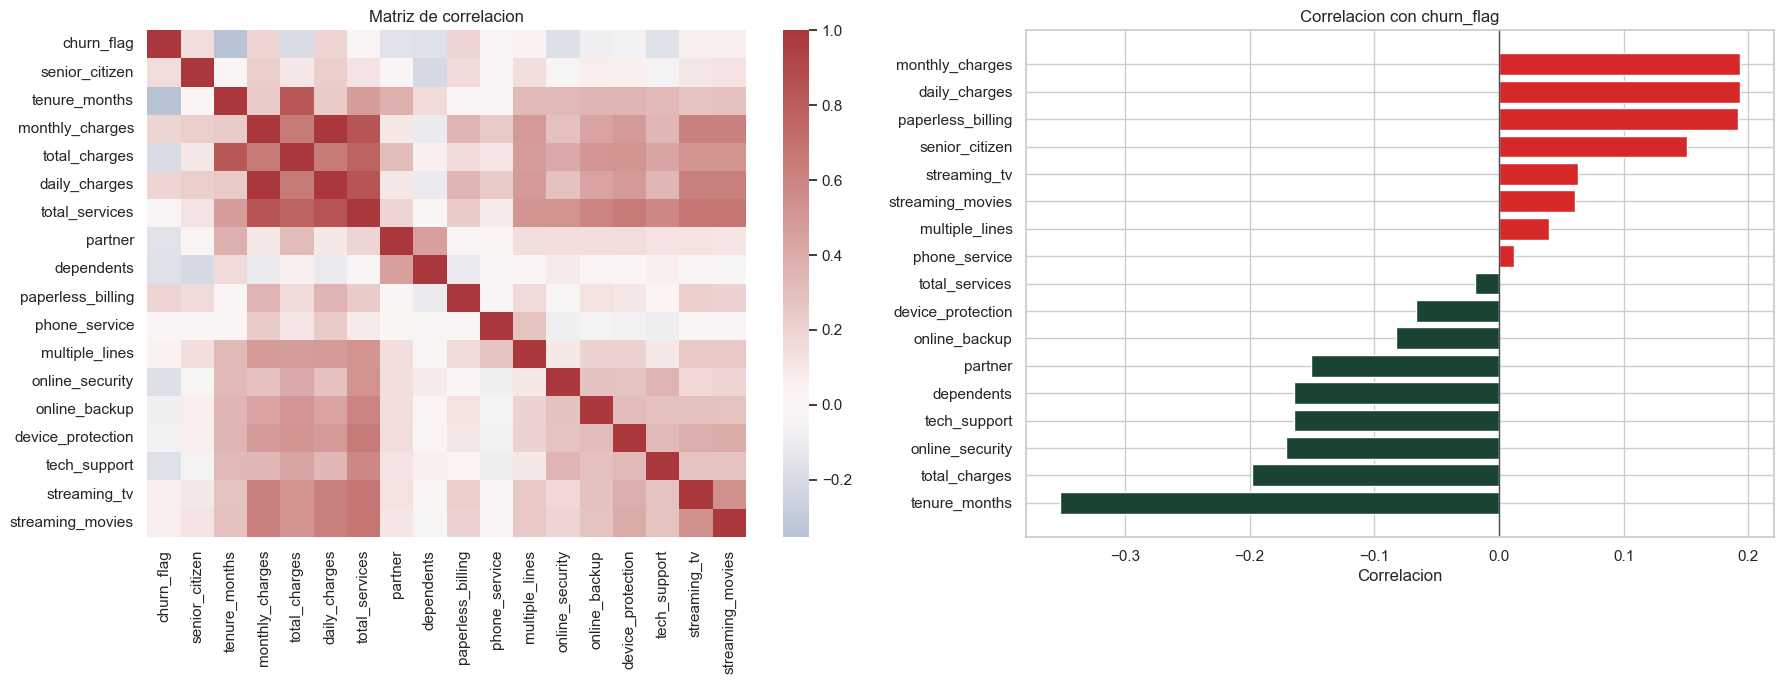

tenure_months       -0.352229
total_charges       -0.198324
online_security     -0.171226
tech_support        -0.164674
dependents          -0.164221
partner             -0.150448
online_backup       -0.082255
device_protection   -0.066160
total_services      -0.019375
phone_service        0.011942
multiple_lines       0.040102
streaming_movies     0.061382
streaming_tv         0.063228
senior_citizen       0.150889
paperless_billing    0.191825
daily_charges        0.193356
monthly_charges      0.193356
churn_flag           1.000000
Name: churn_flag, dtype: float64

In [6]:
corr_fig, target_correlations = plot_correlations(clean_df)
corr_fig.savefig(FIGURES_DIR / "correlations.png", dpi=200, bbox_inches="tight")
plt.show()

target_correlations.sort_values()

Las relaciones mas claras con churn son:

- `tenure_months` y `total_charges` con correlacion negativa.
- `monthly_charges`, `paperless_billing` y `senior_citizen` con correlacion positiva.
- La ausencia de `online_security` y `tech_support` tambien eleva el riesgo.

## 4. Analisis dirigido

Siguiendo el tablero, se revisan las relaciones:

- tiempo de contrato x churn
- gasto total x churn

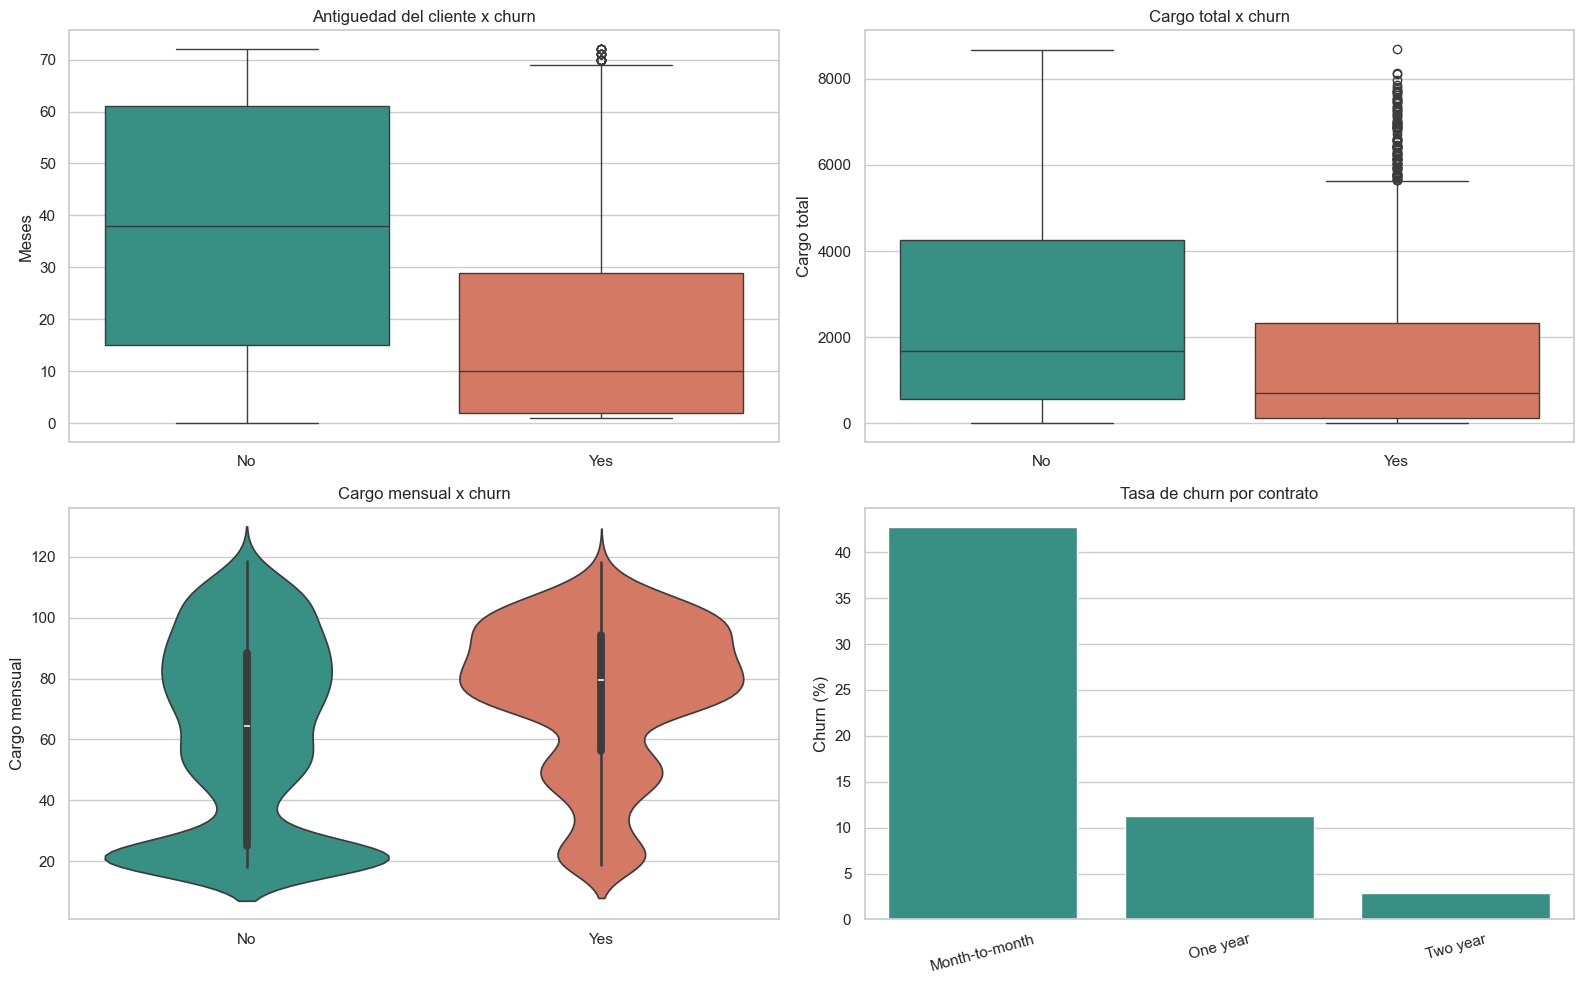

In [7]:
directed_fig = plot_directed_analysis(clean_df)
directed_fig.savefig(FIGURES_DIR / "directed_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
contract_rates = get_categorical_rate_table(clean_df, "contract")
payment_rates = get_categorical_rate_table(clean_df, "payment_method")
internet_rates = get_categorical_rate_table(clean_df, "internet_service")
numeric_summary = get_numeric_summary_by_churn(clean_df)

display(contract_rates)
display(payment_rates)
display(internet_rates)
display(numeric_summary)

,contract,clients,churn_rate
0,Month-to-month,3875,42.71
1,One year,1473,11.27
2,Two year,1695,2.83


,payment_method,clients,churn_rate
0,Electronic check,2365,45.29
1,Mailed check,1612,19.11
2,Bank transfer (automatic),1544,16.71
3,Credit card (automatic),1522,15.24


,internet_service,clients,churn_rate
0,Fiber optic,3096,41.89
1,DSL,2421,18.96
2,No,1526,7.40


,churn,tenure_months_mean,tenure_months_median,monthly_charges_mean,monthly_charges_median,total_charges_mean,total_charges_median,total_services_mean,total_services_median
0,No,37.57,38.0,61.27,64.43,2549.91,1679.52,4.17,4.0
1,Yes,17.98,10.0,74.44,79.65,1531.80,703.55,4.07,4.0


## 5. Modelado predictivo

Se comparan dos enfoques:

- **Regresion Logistica**: requiere estandarizacion.
- **Random Forest**: no requiere escalamiento y captura relaciones no lineales.

In [9]:
X, y = prepare_modeling_dataset(clean_df)
X_train, X_test, y_train, y_test = split_dataset(X, y, test_size=0.2)

print(f"Entrenamiento: {X_train.shape}, Prueba: {X_test.shape}")

Entrenamiento: (5634, 20), Prueba: (1409, 20)


In [10]:
metrics_df, artifacts = compare_models(X_train, X_test, y_train, y_test)
metrics_df

,model,split,accuracy,precision,recall,f1_score,tn,fp,fn,tp
3,Random Forest,test,0.7679,0.5438,0.7807,0.6411,790,245,82,292
1,Logistic Regression,test,0.7395,0.5060,0.7861,0.6157,748,287,80,294
2,Random Forest,train,0.7966,0.5802,0.8441,0.6877,3226,913,233,1262
0,Logistic Regression,train,0.7520,0.5211,0.8107,0.6344,3025,1114,283,1212


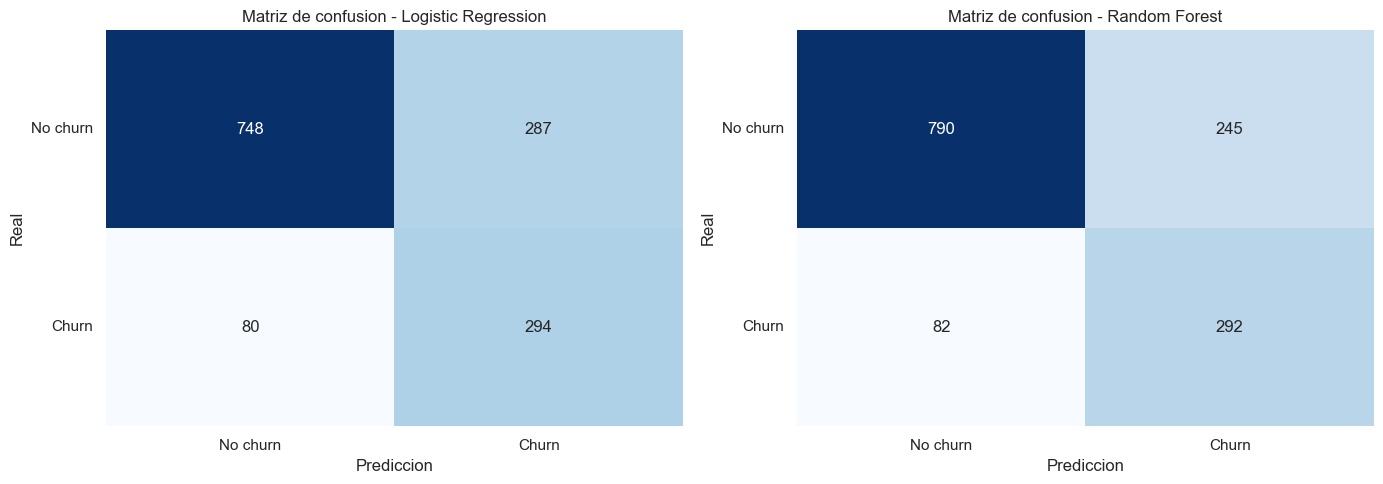

In [11]:
confusion_fig = plot_confusion_matrices(artifacts)
confusion_fig.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Importancia de variables

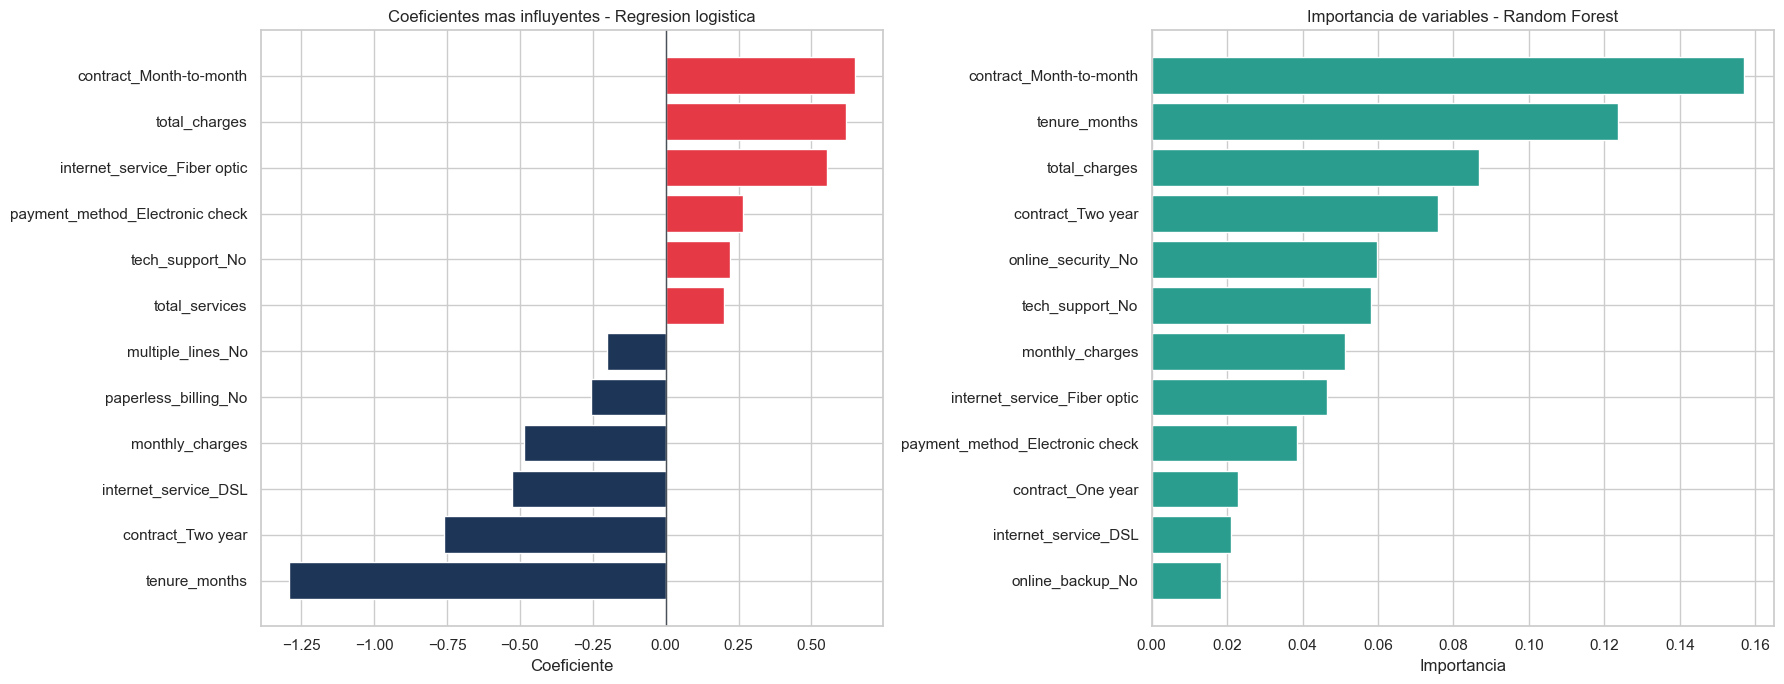

,coefficient
tenure_months,-1.292059
contract_Two year,-0.759577
contract_Month-to-month,0.648443
total_charges,0.619221
internet_service_Fiber optic,0.553800
internet_service_DSL,-0.528400
monthly_charges,-0.486124
payment_method_Electronic check,0.264782
paperless_billing_No,-0.255367
tech_support_No,0.220756


,importance
contract_Month-to-month,0.157131
tenure_months,0.123742
total_charges,0.086777
contract_Two year,0.075777
online_security_No,0.059754
tech_support_No,0.058235
monthly_charges,0.051138
internet_service_Fiber optic,0.046554
payment_method_Electronic check,0.038418
contract_One year,0.022868


In [12]:
logistic_coefficients, random_forest_importances = get_feature_importances(artifacts, top_n=12)

feature_fig = plot_feature_importance(logistic_coefficients, random_forest_importances)
feature_fig.savefig(FIGURES_DIR / "feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()

display(logistic_coefficients.to_frame("coefficient"))
display(random_forest_importances.to_frame("importance"))

## 7. Conclusiones

### Hallazgos tecnicos

- **Random Forest** obtiene el mejor equilibrio global entre exactitud y F1 en prueba.
- **Regresion Logistica** mantiene el mejor recall, por lo que resulta util si el negocio prioriza detectar la mayor cantidad posible de clientes con riesgo de cancelar.
- El ajuste del bosque aleatorio con profundidad limitada reduce el sobreajuste observado en una version mas compleja.

### Variables mas influyentes

- Contrato **Month-to-month**
- Menor **antiguedad**
- Mayor **cargo total / mensual**
- Ausencia de **online security** y **tech support**
- Servicio de internet **Fiber optic**
- Metodo de pago **Electronic check**

### Recomendaciones de negocio

1. Priorizar campanas de retencion temprana para clientes con menos antiguedad y contrato mensual.
2. Ofrecer bundles con seguridad y soporte tecnico para clientes de Fiber optic.
3. Revisar fricciones del canal `Electronic check`, que concentra la tasa mas alta de cancelacion.
4. Usar la regresion logistica como modelo de alerta temprana y el Random Forest como referencia operativa por su mejor balance general.